In [120]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
"""设置画布中文和负号设置"""
plt.rcParams['font.sans-serif']    = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False      # 用来正常显示负号
plt.rcParams['figure.dpi']         = 100        #分辨率

In [121]:
"""设置本次项目的设备环境"""
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu")
'''设置模型数据保存地址'''
save_dir = "../HandWrittenRecog/savepoints"
save_file = "checkpoints.pt"
points_path = os.path.join(save_dir,save_file)
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [122]:
"""加载MNISET图片数据"""
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.1307,),(0.3081,))])  #设置加载图片方式，先转化为张量，再标准化，其中0.1307为均值，0.3081为标准差
dataset_root = "../HandWrittenRecog/dataset"
train_dataset = datasets.MNIST(root=dataset_root,download=True,train=True,transform=transform)
tests_dataset = datasets.MNIST(root=dataset_root,download=True,train=False,transform=transform)
batch_size = 32
train_dataloader = DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=True)
tests_dataloader = DataLoader(dataset=tests_dataset,batch_size=batch_size,shuffle=True)

f:\pytorch practice\.venv\Lib\site-packages\torchvision\datasets\mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


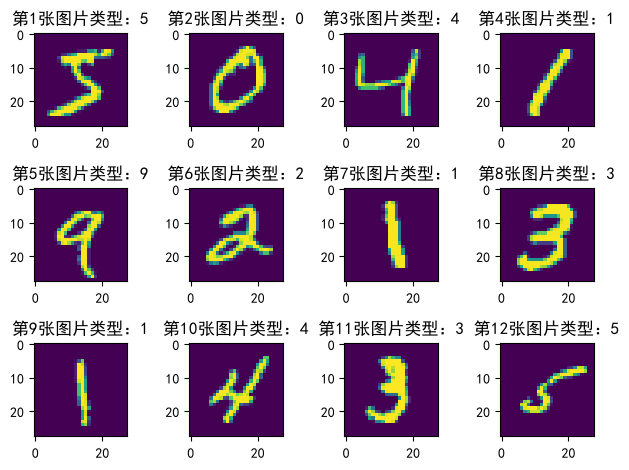

In [123]:
"""查看部分训练数据图片"""
fig = plt.figure()
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.tight_layout()
    plt.imshow(train_dataset.data[i])
    plt.title(f"第{i+1}张图片类型：{train_dataset.train_labels[i]}")
    plt.xticks()
    plt.yticks()
plt.show()

In [124]:
"""构建卷积神经网络"""
class cnn(torch.nn.Module):
    def __init__(self):
        super(cnn,self).__init__()
        """输入尺寸1x28x28"""
        """第一层卷积输出尺寸32x13x13"""
        self.conv1 = nn.Sequential(
            nn.Conv2d(1,32,kernel_size=3),  #输入1，输出32，卷积核3x3
            nn.BatchNorm2d(32),             #对输出进行标准化操作
            nn.ReLU(),                      #非线性
            nn.MaxPool2d(kernel_size=2)     #最大池化，提取最大特征，减少计算
        )
        """第二层卷积输出尺寸64x5x5"""
        self.conv2 = nn.Sequential(
            nn.Conv2d(32,64,kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        """全连接层输入为64x5x5=1600"""
        self.fc = nn.Sequential(
            nn.Linear(1600,50),   #把1600个特征压缩到50个
            nn.ReLU(),
            nn.Dropout(0.5),      #设置0.5的dropout
            nn.Linear(50,10),     #最终输出10个类别特征概率
        )
    def forward(self,x):
        """先进行两轮卷积"""
        x = self.conv1(x)
        x = self.conv2(x)
        """然后摊平x"""
        x = torch.flatten(x,start_dim=1)
        """送进全连接层"""
        x = self.fc(x)
        return x

In [125]:
'''加载已经训练的模型参数（如果存在）'''
check_point = None
if(os.path.exists(points_path)):
    check_point = torch.load(points_path)

In [126]:
"""观察网络参数"""
model = cnn().to(device)
if(check_point):
    model.load_state_dict(check_point["model"])
def count_parameters(model):
    all_parameters = sum(p.numel() for p in model.parameters())
    train_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"模型的所有参数为{all_parameters}")
    print(f"模型的训练参数为{train_parameters}")
print(model)
count_parameters(model)

cnn(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=1600, out_features=50, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=50, out_features=10, bias=True)
  )
)
模型的所有参数为99568
模型的训练参数为99568


In [127]:
"""设置优化器和损失函数"""
loss_fc = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(),lr=0.05)
if(check_point):
    optimizer.load_state_dict(check_point["optimizer"])

In [128]:
"""编写训练代码"""
def train(model,optimizer,loss_fc,train_dataloader):
    average_loss = 0
    average_acc = 0
    batch_num = 0
    for batchx,batchy in train_dataloader:
        #梯度清零
        optimizer.zero_grad()
        #加载训练数据
        batchx = batchx.to(device)
        batchy = batchy.to(device)
        #预测并计算损失
        pred = model(batchx)
        loss = loss_fc(pred,batchy)
        #反馈
        loss.backward()
        optimizer.step()
        batch_num += batchy.size(0)
        average_loss += loss.item()*batchy.size(0)
        average_acc += (pred.argmax(dim=1)==batchy).float().sum().item()
    average_acc /= batch_num
    average_loss /= batch_num
    return average_loss,average_acc

In [129]:
"""编写预测函数"""
def test(model,loss_fc,dataloader):
    average_acc = 0
    average_loss = 0
    batch_num = 0
    with torch.no_grad():
        for batchx,batchy in dataloader:
            batchx = batchx.to(device)
            batchy = batchy.to(device)

            pred = model(batchx)
            loss = loss_fc(pred,batchy)

            average_loss += loss.item()*batchy.size(0)
            average_acc += (pred.argmax(dim=1)==batchy).float().sum().item()
            batch_num += batchy.size(0)
        average_acc /= batch_num
        average_loss /= batch_num
    return average_loss,average_acc

In [130]:
"""开始训练并测试"""
epoches = 10    #训练轮次为200轮
train_loss_list = check_point["train_loss"] if check_point else []
train_acc_list = check_point["train_acc"] if check_point else []
test_loss_list = check_point["test_loss"] if check_point else []
test_acc_list = check_point["test_acc"] if check_point else []
for epoch in range(epoches):
    model.train()
    train_loss,train_acc = train(model,optimizer,loss_fc,train_dataloader)
    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)
    model.eval()
    test_loss,test_acc = test(model,loss_fc,tests_dataloader)
    test_acc_list.append(test_acc)
    test_loss_list.append(test_loss)
    print(f"第{epoch+1}轮训练，训练损失为{train_loss:.4f}，训练准确率为{train_acc*100:.4f}%，测试损失为{test_loss:.4f}，测试准确率为{test_acc*100:.4f}%")


第1轮训练，训练损失为0.0557，训练准确率为98.1933%，测试损失为0.0268，测试准确率为99.1300%
第2轮训练，训练损失为0.0502，训练准确率为98.3550%，测试损失为0.0233，测试准确率为99.2300%
第3轮训练，训练损失为0.0467，训练准确率为98.4550%，测试损失为0.0253，测试准确率为99.1900%
第4轮训练，训练损失为0.0442，训练准确率为98.5700%，测试损失为0.0211，测试准确率为99.3500%
第5轮训练，训练损失为0.0441，训练准确率为98.5650%，测试损失为0.0255，测试准确率为99.2000%
第6轮训练，训练损失为0.0385，训练准确率为98.7533%，测试损失为0.0252，测试准确率为99.1800%
第7轮训练，训练损失为0.0379，训练准确率为98.7500%，测试损失为0.0268，测试准确率为99.1700%
第8轮训练，训练损失为0.0381，训练准确率为98.7733%，测试损失为0.0250，测试准确率为99.2300%
第9轮训练，训练损失为0.0343，训练准确率为98.8717%，测试损失为0.0240，测试准确率为99.2700%
第10轮训练，训练损失为0.0299，训练准确率为99.0333%，测试损失为0.0255，测试准确率为99.2900%


In [131]:
"""保存模型"""
save_dic = {
    "train_loss":train_loss_list,
    "train_acc":train_acc_list,
    "test_loss":test_loss_list,
    "test_acc":test_acc_list,
    "model":model.state_dict(),
    "optimizer":optimizer.state_dict()
}
torch.save(save_dic,os.path.join(save_dir,save_file))

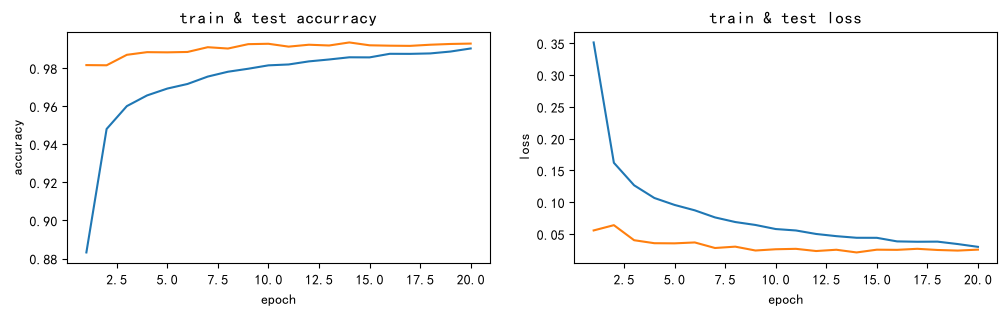

In [132]:
"""绘制曲线"""
xlabel = [i+1 for i in range(len(train_loss_list))]

plt.figure(figsize=(12,3))
plt.subplot(1,2,1)
plt.plot(xlabel,train_acc_list,label="training accuracy")
plt.plot(xlabel,test_acc_list,label="testing accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("train & test accurracy")

plt.subplot(1,2,2)
plt.plot(xlabel,train_loss_list,label="training loss")
plt.plot(xlabel,test_loss_list,label="testing loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("train & test loss")

plt.show()